<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/Colebank_100K_Folder/EarlyFusionCNN_Optimized_cleaner_100K.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Early Fusion CNN Optimized

Jennifer's updated version

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Mounted at /content/drive
/content/drive/MyDrive/REU ECG Analysis
BCNN		    ECG_waveforms_1K.npy      outputs
ECG_metrics_1K.npy  EchoNext_EchoData_5K.csv  PaperFigures


Using device: cuda
Beginning execution pipeline...
Training model...

===== Individual Test Sample Inference Profiles ====
Sample 000 | True: 1 | Pred: 1 | Confidence: 0.6944 | Uncertainty (Std): 0.0000
Sample 001 | True: 1 | Pred: 1 | Confidence: 0.9998 | Uncertainty (Std): 0.0000
Sample 002 | True: 1 | Pred: 1 | Confidence: 0.5748 | Uncertainty (Std): 0.0000
Sample 003 | True: 0 | Pred: 0 | Confidence: 0.8721 | Uncertainty (Std): 0.0000
Sample 004 | True: 1 | Pred: 1 | Confidence: 0.6918 | Uncertainty (Std): 0.0000
Sample 005 | True: 1 | Pred: 1 | Confidence: 0.5274 | Uncertainty (Std): 0.0000
Sample 006 | True: 0 | Pred: 0 | Confidence: 0.9198 | Uncertainty (Std): 0.0000
Sample 007 | True: 0 | Pred: 0 | Confidence: 0.5453 | Uncertainty (Std): 0.0000
Sample 008 | True: 0 | Pred: 1 | Confidence: 0.6573 | Uncertainty (Std): 0.0000
Sample 009 | True: 0 | Pred: 0 | Confidence: 0.9111 | Uncertainty (Std): 0.0000
Sample 010 | True: 0 | Pred: 1 | Confidence: 0.8718 | Uncertainty (Std): 0.00

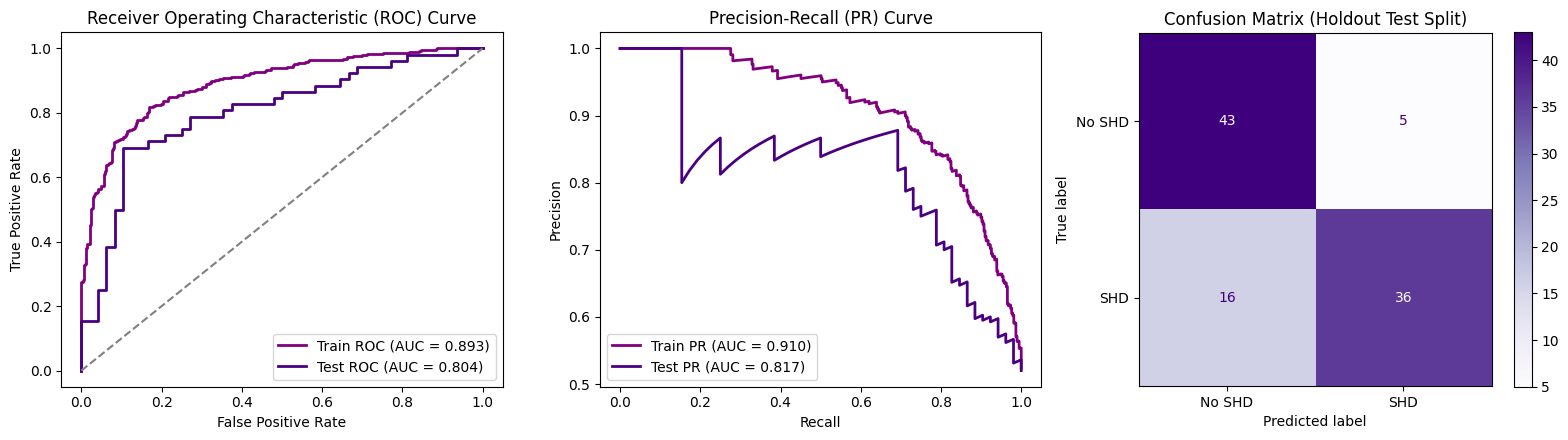

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, roc_curve,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
)

# ──────────────────────────────────────────────────────────────────────
# 3. PYTORCH DATA STRUCTURING
# ──────────────────────────────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts, X_demo, y):
        assert len(X_ts) == len(X_demo) == len(y), "Length mismatch across tensor targets."
        self.X_ts = torch.tensor(X_ts, dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]

# ──────────────────────────────────────────────────────────────────────
# 4. DETERMINISTIC FiLM NETWORK ARCHITECTURE (NO BLITZ/BAYESIAN)
# ──────────────────────────────────────────────────────────────────────
class FiLMLayer(nn.Module):
    def __init__(self, demo_embed_dim, num_channels):
        super().__init__()
        self.film_proj = nn.Linear(demo_embed_dim, 2 * num_channels)

    def forward(self, h, demo_embed):
        params = self.film_proj(demo_embed)
        gamma, beta = params.chunk(2, dim=-1)
        return gamma.unsqueeze(-1) * h + beta.unsqueeze(-1)

class FiLMConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, pool_size, demo_embed_dim, pool_type="avg"):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm1d(out_channels)
        self.film = FiLMLayer(demo_embed_dim, out_channels)
        self.act = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1) if pool_type == "gap" else nn.AvgPool1d(kernel_size=pool_size)

    def forward(self, x, demo_embed):
        return self.pool(self.act(self.film(self.bn(self.conv(x)), demo_embed)))

class HeartDiseaseNet(nn.Module):
    def __init__(self, sequence_length, in_channels, demo_dim, num_classes=2, demo_embed_dim=16):
        super().__init__()
        self.demo_encoder = nn.Sequential(
            nn.Linear(demo_dim, demo_embed_dim),
            nn.ReLU()
        )
        self.block1 = FiLMConvBlock(in_channels, 16, kernel_size=15, padding=7, pool_size=10, demo_embed_dim=demo_embed_dim, pool_type="avg")
        self.block2 = FiLMConvBlock(16, 32, kernel_size=9, padding=4, pool_size=10, demo_embed_dim=demo_embed_dim, pool_type="avg")
        self.block3 = FiLMConvBlock(32, 32, kernel_size=5, padding=2, pool_size=None, demo_embed_dim=demo_embed_dim, pool_type="gap")

        with torch.no_grad():
            dummy_ts = torch.zeros(1, in_channels, sequence_length)
            dummy_demo = torch.zeros(1, demo_embed_dim)
            x = self.block3(self.block2(self.block1(dummy_ts, dummy_demo), dummy_demo), dummy_demo)
            flat_sz = x.shape[1] * x.shape[2]

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_sz, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x_ts, x_demo):
        demo_embed = self.demo_encoder(x_demo)
        return self.head(self.block3(self.block2(self.block1(x_ts, demo_embed), demo_embed), demo_embed))

# ──────────────────────────────────────────────────────────────────────
# 5. TRAINING ROUTINE
# ──────────────────────────────────────────────────────────────────────
def train_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    for epoch in range(epochs):
        model.train()
        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)
            X_ts_b += 0.05 * torch.randn_like(X_ts_b)

            optimizer.zero_grad()
            logits = model(X_ts_b, X_demo_b)
            loss = criterion(logits, y_b)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss, val_total = 0.0, 0
        with torch.no_grad():
            for X_ts_v, X_demo_v, y_v in val_loader:
                X_ts_v, X_demo_v, y_v = X_ts_v.to(device), X_demo_v.to(device), y_v.to(device)
                logits = model(X_ts_v, X_demo_v)
                val_loss += criterion(logits, y_v).item() * X_ts_v.shape[0]
                val_total += X_ts_v.shape[0]

        epoch_val_loss = val_loss / val_total
        print(f"Epoch {epoch+1:02d} | Dedicated Validation Loss: {epoch_val_loss:.6f}")
        scheduler.step(epoch_val_loss)

# ──────────────────────────────────────────────────────────────────────
# 6. PERFORMANCE METRICS GENERATION & CALIBRATION ESTIMATION
# ──────────────────────────────────────────────────────────────────────
def calculate_calibration_error(probs, labels, bins=10):
    bin_boundaries = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for i in range(bins):
        bin_lower, bin_upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def get_predictions_and_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    all_nll = 0.0
    criterion = nn.CrossEntropyLoss(reduction='sum')

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            logits = model(X_ts_b, X_demo_b)
            probs = torch.softmax(logits, dim=-1)

            all_nll += criterion(torch.log(probs + 1e-8), y_b.to(device)).item()
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y_b.numpy())

    return np.array(all_probs), np.array(all_labels), all_nll / len(loader.dataset)

def generate_and_display_comparative_metrics(model, train_loader, test_loader):
    train_probs, train_labels, train_nll = get_predictions_and_labels(model, train_loader)
    test_probs, test_labels, test_nll = get_predictions_and_labels(model, test_loader)

    train_preds = (train_probs >= 0.5).astype(int)
    test_preds = (test_probs >= 0.5).astype(int)

    metrics_map = {
        "accuracy": (np.mean(train_preds == train_labels), np.mean(test_preds == test_labels)),
        "auroc": (roc_auc_score(train_labels, train_probs), roc_auc_score(test_labels, test_probs)),
        "auprc": (None, None),
        "brier_score": (brier_score_loss(train_labels, train_probs), brier_score_loss(test_labels, test_probs)),
        "negative_log_likelihood": (train_nll, test_nll),
        "expected_calibration_error": (calculate_calibration_error(train_probs, train_labels), calculate_calibration_error(test_probs, test_labels))
    }

    train_precision, train_recall, _ = precision_recall_curve(train_labels, train_probs)
    train_fpr, train_tpr, _ = roc_curve(train_labels, train_probs)
    metrics_map["auprc"] = (auc(train_recall, train_precision), metrics_map["auprc"][1])

    test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
    test_fpr, test_tpr, _ = roc_curve(test_labels, test_probs)
    metrics_map["auprc"] = (metrics_map["auprc"][0], auc(test_recall, test_precision))

    tn_tr, fp_tr, fn_tr, tp_tr = confusion_matrix(train_labels, train_preds).ravel()
    tn_te, fp_te, fn_te, tp_te = confusion_matrix(test_labels, test_preds).ravel()

    metrics_map["tn"] = (float(tn_tr), float(tn_te))
    metrics_map["fp"] = (float(fp_tr), float(fp_te))
    metrics_map["fn"] = (float(fn_tr), float(fn_te))
    metrics_map["tp"] = (float(tp_tr), float(tp_te))

    print("\nClassification metrics (train vs. test):")
    print(f"{'':<28} {'train':<10} {'test':<10}")
    for k, v in metrics_map.items():
        print(f"{k:<28} {v[0]:.6f}   {v[1]:.6f}")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    ax[0].plot(train_fpr, train_tpr, color='teal', lw=2, label=f'Train ROC (AUC = {metrics_map["auroc"][0]:.3f})')
    ax[0].plot(test_fpr, test_tpr, color='orange', lw=2, label=f'Test ROC (AUC = {metrics_map["auroc"][1]:.3f})')
    ax[0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].set_title('Receiver Operating Characteristic (ROC) Curve')
    ax[0].legend(loc='lower right')

    ax[1].plot(train_recall, train_precision, color='teal', lw=2, label=f'Train PR (AUC = {metrics_map["auprc"][0]:.3f})')
    ax[1].plot(test_recall, test_precision, color='orange', lw=2, label=f'Test PR (AUC = {metrics_map["auprc"][1]:.3f})')
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('Precision-Recall (PR) Curve')
    ax[1].legend(loc='lower left')

    cm_test = confusion_matrix(test_labels, test_preds)
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No SHD", "SHD"]).plot(ax=ax[2], cmap="Blues", values_format="d")
    ax[2].set_title("Confusion Matrix (Holdout Test Split)")

    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────────────────────────────
# 7. EXECUTION PIPELINE (CONTINUATION FROM PREPROCESSING)
# ──────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create Dataloaders (with explicit validation loader)
train_loader = DataLoader(FusedDataset(X_ts_train, X_demo_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(FusedDataset(X_ts_val,   X_demo_val,   y_val),   batch_size=128, shuffle=False)
test_loader  = DataLoader(FusedDataset(X_ts_test,  X_demo_test,  y_test),  batch_size=128, shuffle=False)

# ── STEP E: INITIALIZE & TRAIN THE MODEL ──
model = HeartDiseaseNet(
    sequence_length=X_ts_train.shape[2], in_channels=X_ts_train.shape[1],
    demo_dim=X_demo_train.shape[1], num_classes=2, demo_embed_dim=32
)

print("Training model...")
train_classifier(model, train_loader, val_loader, epochs=60, learning_rate=1e-4)

torch.manual_seed(RANDOM_SEED)

# ── STEP F: PRINT SAMPLE INDIVIDUAL INFERENCE RECORDS ──
print("\n===== Individual Test Sample Inference Profiles ====")
model.eval()
sample_counter = 0

with torch.no_grad():
    for X_ts_b, X_demo_b, y_b in test_loader:
        X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
        logits = model(X_ts_b, X_demo_b)
        probs = torch.softmax(logits, dim=-1).cpu().numpy()

        for idx in range(X_ts_b.size(0)):
            true_val = y_b[idx].item()
            pred_val = np.argmax(probs[idx])
            confidence = probs[idx][pred_val]
            global_df_idx = test_ids[sample_counter]

            print(f"Sample {sample_counter:03d} (DF Index: {global_df_idx:03d}) | "
                  f"True: {true_val} | Pred: {pred_val} | "
                  f"Confidence: {confidence:.4f}")
            sample_counter += 1

# ── STEP G: SYSTEM METRICS ANALYSIS VISUALIZATIONS ──
generate_and_display_comparative_metrics(model, train_loader, test_loader)